In [1]:
import pandas as pd
import joblib
import dill
from sklearn.preprocessing import StandardScaler
from incdbscan.incrementaldbscan import IncrementalDBSCAN
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [92]:
METRICS = [
    'Velocity_Anomaly',
    'Value_Anomaly',
    'TimeGap_Anomaly',
    'Location_Anomaly',
    'Network_Anomaly'
]

EPS_VALUE = 0.7
MIN_SAMPLES_VALUE = 6
SCALER_FILENAME = 'scaler.pkl'

data_history = pd.read_csv('data_history_min.csv')
X_history = data_history[METRICS].fillna(0)

scaler = StandardScaler()
scaler.fit(X_history)
joblib.dump(scaler, SCALER_FILENAME)
print(f"✅ Scaler đã lưu vào '{SCALER_FILENAME}'")

X_history_scaled = scaler.transform(X_history)

✅ Scaler đã lưu vào 'scaler.pkl'


In [93]:
idbscan_model = IncrementalDBSCAN(eps=EPS_VALUE, min_pts=MIN_SAMPLES_VALUE)
idbscan_model.insert(X_history_scaled)

In [94]:
labels = idbscan_model.get_cluster_labels(X_history_scaled)
num_clusters = len(set(labels) - {-1}) 
print(f"Huấn luyện history hoàn tất. Số cụm: {num_clusters}")

data_history_results = data_history.copy()
data_history_results['cluster_label'] = labels
data_history_results['is_anomaly'] = data_history_results['cluster_label'] == -1

print("\n--- Kết quả Phân cụm Dữ liệu Lịch sử ---")
print(data_history_results.head(10))

Huấn luyện history hoàn tất. Số cụm: 6

--- Kết quả Phân cụm Dữ liệu Lịch sử ---
   transaction_id            timestamp sender_account receiver_account  \
0            4947  2025-05-01 00:03:00    ACC72727011      ACC20053358   
1            2926  2025-05-01 00:04:00    ACC70847404      ACC42997680   
2            2903  2025-05-01 00:32:00    ACC57391095      ACC30818005   
3            7566  2025-05-01 01:45:00    ACC51450856      ACC25950190   
4            5670  2025-05-01 01:48:00    ACC54501777      ACC96809814   
5            5700  2025-05-01 02:09:00    ACC90771158      ACC59898608   
6            4993  2025-05-01 02:13:00    ACC13065064      ACC23805217   
7               1  2025-05-01 02:50:00    ACC83943848      ACC63535885   
8            3382  2025-05-01 03:18:00    ACC65067486      ACC35928416   
9            7222  2025-05-01 03:34:00    ACC47962723      ACC87961799   

   amount   location       ip_address                       device_hash  \
0   25651   Dong Nai    83.16

In [95]:
import umap

reducer = umap.UMAP(n_components=2) 

embedding = reducer.fit_transform(X_history_scaled)

C:\Users\thanh\AppData\Local\Temp\ipykernel_17244\1692483049.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Spectral', n_labels_total)


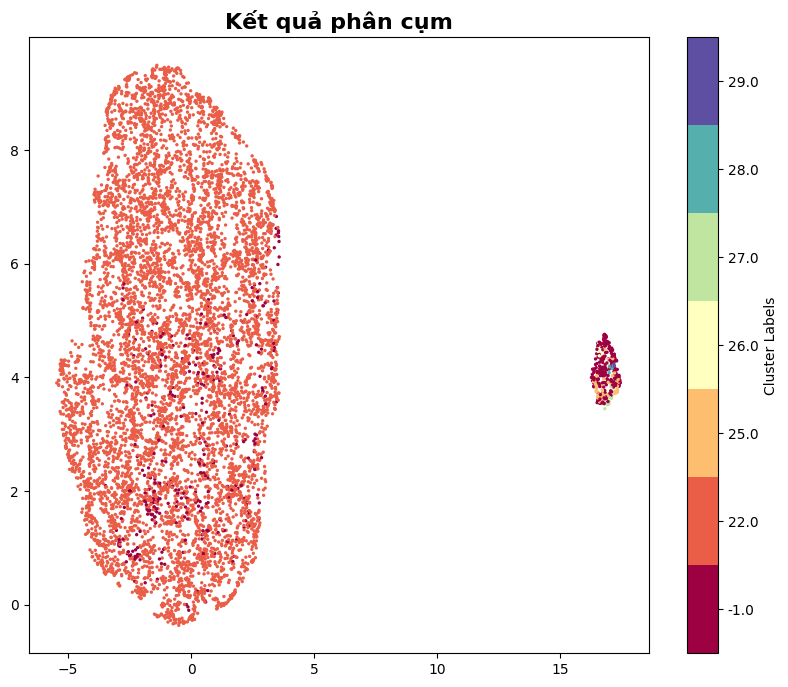

In [96]:
unique_labels = np.unique(labels)
n_labels_total = len(unique_labels)

label_map = {old_label: i for i, old_label in enumerate(unique_labels)}

mapped_labels = np.array([label_map[label] for label in labels])

cmap = plt.cm.get_cmap('Spectral', n_labels_total) 

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    c=mapped_labels,
    cmap=cmap,         
    s=2,              
    vmin=-0.5,
    vmax=n_labels_total - 0.5 
)

boundaries = np.arange(n_labels_total + 1) - 0.5
ticks = np.arange(n_labels_total)

cbar = plt.colorbar(
    scatter, 
    label='Cluster Labels',
    boundaries=boundaries,
    ticks=ticks
)

cbar.set_ticklabels(unique_labels) 

plt.title("Kết quả phân cụm", fontweight='bold', fontsize=16)
plt.show()

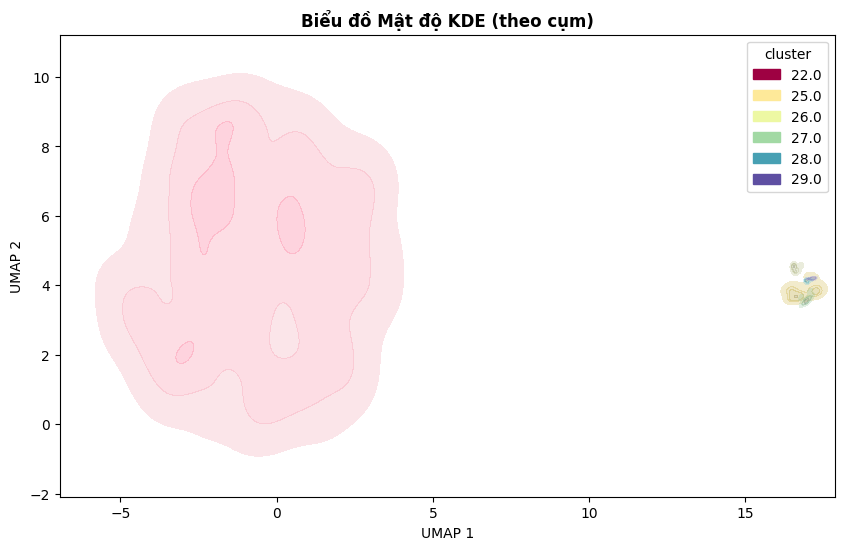

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Giả sử bạn đã có: ---
# embedding = ... (dữ liệu 2D, ví dụ: 40000x2)
# cluster_labels = ... (mảng nhãn cụm)
# -------------------------

# 1. Tạo DataFrame để Seaborn hoạt động
# (Seaborn hoạt động tốt nhất với DataFrame)
df_embed = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])
df_embed['cluster'] = labels

# 2. Lọc bỏ nhiễu (-1) để tập trung vào các cụm
df_clusters_only = df_embed[df_embed['cluster'] != -1]

plt.figure(figsize=(10, 6))

# 3. Vẽ biểu đồ KDE
sns.kdeplot(
    data=df_clusters_only,
    x='UMAP 1',
    y='UMAP 2',
    hue='cluster',      # <-- Tô màu đường viền theo cụm
    palette='Spectral', # Dùng dải màu
    fill=True,          # Tô màu bên trong (đặt là False nếu chỉ muốn đường viền)
    alpha=0.3,          # Độ trong suốt của màu tô
    levels=5            # Số lượng đường đồng mức
)

plt.title("Biểu đồ Mật độ KDE (theo cụm)", fontweight='bold')
plt.show()

In [98]:
data_streaming = pd.read_csv('data_stream_min.csv')
X_streaming = data_streaming[METRICS].fillna(0)

X_streaming_scaled = scaler.transform(X_streaming)

idbscan_model.insert(X_streaming_scaled)

streaming_labels = idbscan_model.get_cluster_labels(X_streaming_scaled)

streaming_results = data_streaming.copy()
streaming_results['cluster_label'] = streaming_labels
streaming_results['is_anomaly'] = streaming_results['cluster_label'] == -1

print("\n--- Kết quả Phân cụm Dữ liệu Streaming ---")
print(streaming_results.head(10))


--- Kết quả Phân cụm Dữ liệu Streaming ---
   transaction_id            timestamp sender_account receiver_account  \
0            5817  2025-09-24 18:21:00    ACC44379722      ACC91183086   
1            2883  2025-09-24 18:47:00    ACC47793751      ACC94164823   
2            9707  2025-09-24 18:54:00    ACC93241935      ACC26680684   
3             634  2025-09-24 19:17:00    ACC80957100      ACC70628227   
4            8814  2025-09-24 19:23:00    ACC78983997      ACC46688224   
5            2459  2025-09-24 20:05:00    ACC62526698      ACC91425594   
6            7561  2025-09-24 20:06:00    ACC84770025      ACC25759342   
7            4407  2025-09-24 21:11:00    ACC43643054      ACC78915347   
8            2011  2025-09-24 21:25:00    ACC16982465      ACC24403080   
9            2149  2025-09-24 21:56:00    ACC49011005      ACC49532403   

   amount     location       ip_address                       device_hash  \
0  121716       Ha Noi     71.193.84.61  fa214f0229c1df31c98907d

In [99]:
embedding_new = reducer.transform(X_streaming_scaled)

C:\Users\thanh\AppData\Local\Temp\ipykernel_17244\1560485782.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Spectral', n_labels_total)
C:\Users\thanh\AppData\Local\Temp\ipykernel_17244\1560485782.py:53: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


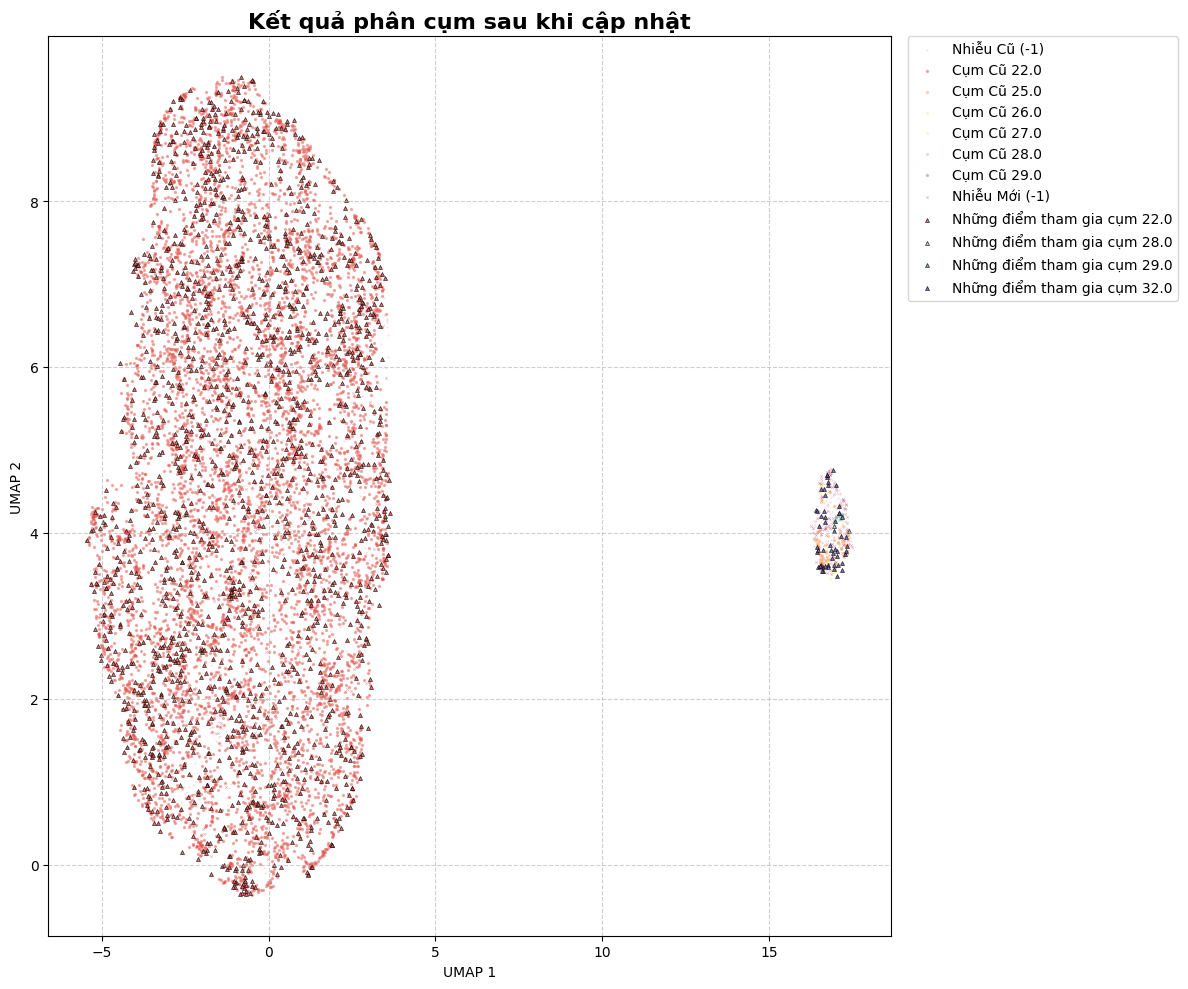

In [ ]:
plt.figure(figsize=(12, 10))

all_unique_labels = np.unique(np.concatenate((labels, streaming_labels)))
n_labels_total = len(all_unique_labels)

label_map = {old_label: i for i, old_label in enumerate(all_unique_labels)}

cmap = plt.cm.get_cmap('Spectral', n_labels_total)

for original_label in np.unique(labels):
    current_mask = (labels == original_label)
    points_to_plot = embedding[current_mask]
    
    mapped_label_for_color = label_map[original_label]
    color = cmap(mapped_label_for_color)

    if original_label == -1:
        alpha_val = 0.08
        point_size = 0.5
        label_text = 'Nhiễu Cũ (-1)'
    else:
        alpha_val = 0.4
        point_size = 2
        label_text = f'Cụm Cũ {original_label}'
        
    plt.scatter(
        points_to_plot[:, 0], 
        points_to_plot[:, 1], 
        c=[color],         
        s=point_size,
        alpha=alpha_val,
        label=label_text
    )

for new_label in np.unique(streaming_labels):
    current_mask = (streaming_labels == new_label)
    points_to_plot_new = embedding_new[current_mask]
    
    mapped_label_for_color = label_map[new_label]
    color = cmap(mapped_label_for_color)

    if new_label == -1:
        alpha_val = 0.3
        point_size = 3
        marker_style = 'x'
        label_text = 'Nhiễu Mới (-1)'
    else:
        alpha_val = 0.8
        point_size = 8 
        marker_style = '^'
        label_text = f'Những điểm tham gia cụm {new_label}'
        
    plt.scatter(
        points_to_plot_new[:, 0], 
        points_to_plot_new[:, 1], 
        c=[color],         
        s=point_size,
        alpha=alpha_val,
        marker=marker_style,
        label=label_text,
        edgecolors='black',
        linewidths=0.5
    )


plt.title("Kết quả phân cụm sau khi cập nhật", fontweight='bold', fontsize=16)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\thanh\AppData\Local\Temp\ipykernel_17244\1355193994.py:48: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


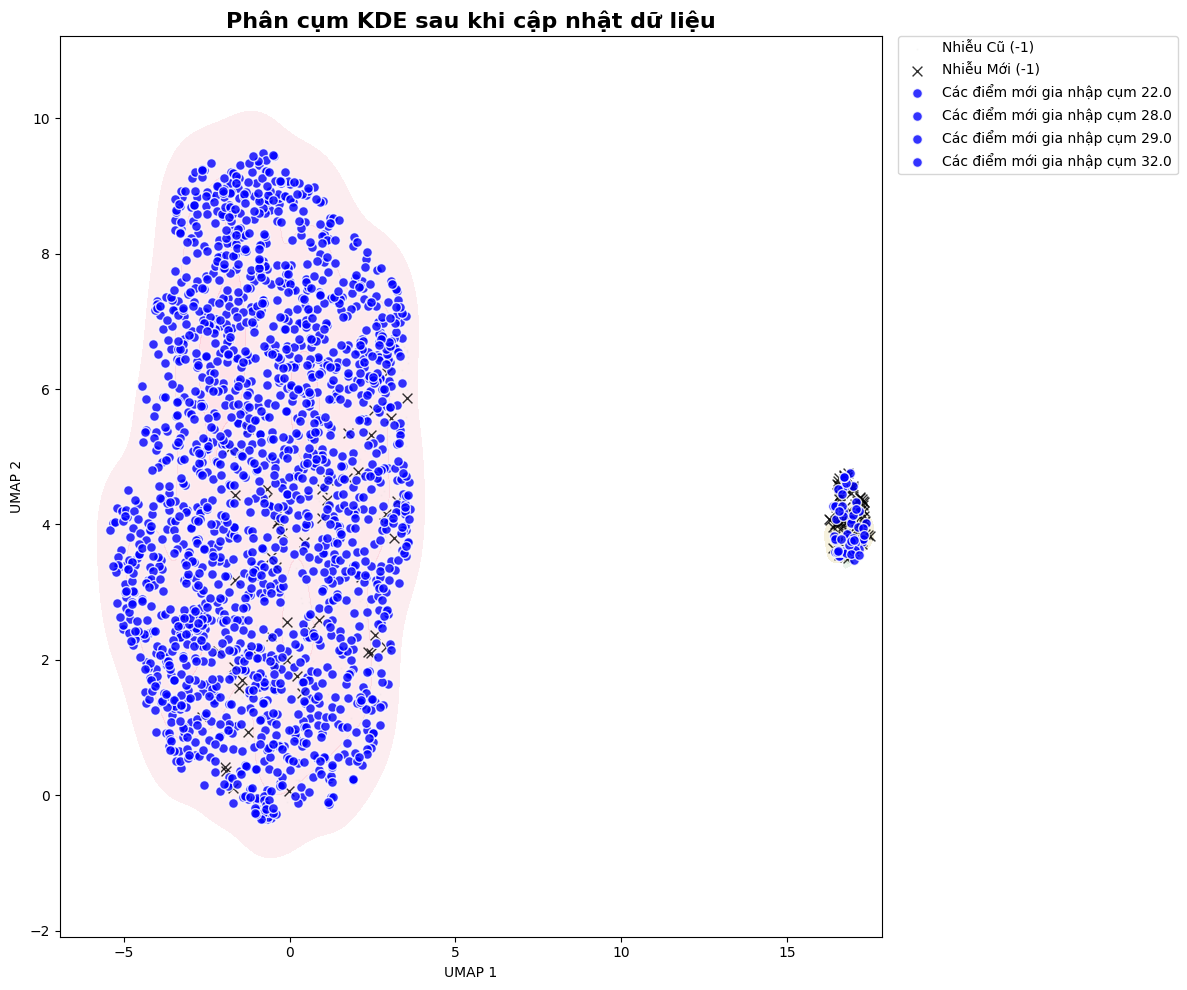

In [102]:
df_embed_original = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])
df_embed_original['cluster'] = labels

df_original_clusters_only = df_embed_original[df_embed_original['cluster'] != -1]
df_original_noise_only = df_embed_original[df_embed_original['cluster'] == -1]

df_embed_new = pd.DataFrame(embedding_new, columns=['UMAP 1', 'UMAP 2'])
df_embed_new['cluster'] = streaming_labels

plt.figure(figsize=(12, 10))
ax = plt.gca()

sns.kdeplot(
    data=df_original_clusters_only,
    x='UMAP 1',
    y='UMAP 2',
    hue='cluster',      
    palette='Spectral', 
    fill=True,          
    alpha=0.2,          
    levels=5,
    ax=ax,
    legend=True
)

ax.scatter(
    df_original_noise_only['UMAP 1'],
    df_original_noise_only['UMAP 2'],
    c='lightgray',      
    s=0.5,              
    alpha=0.1,          
    label='Nhiễu Cũ (-1)'
)

for new_label in np.unique(df_embed_new['cluster']):
    current_mask = (df_embed_new['cluster'] == new_label)
    points_to_plot_new = df_embed_new[current_mask]
    
    if new_label == -1:
        color = 'black'
        marker_style = 'x'
        label_text = 'Nhiễu Mới (-1)'
    else:
        color = 'blue' 
        marker_style = 'o'
        label_text = f'Các điểm mới gia nhập cụm {new_label}'
        
    ax.scatter(
        points_to_plot_new['UMAP 1'], 
        points_to_plot_new['UMAP 2'], 
        c=color,         
        s=50,
        alpha=0.8,
        marker=marker_style,
        label=label_text,
        edgecolors='white',
        linewidths=1
    )

ax.set_title("Phân cụm KDE sau khi cập nhật dữ liệu", fontweight='bold', fontsize=16)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()